In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [44]:
data = pd.read_csv('C:\\Users\\techa\\OneDrive\\Desktop\\dsa_projects\\amazon_music_clus\\single_genre_artists.csv')
data.head(30)

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.3250,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.1280,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.4180,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.2190,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.3730,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22
5,6sVxCBvLSd9PZA7prJn53O,Oh mademoiselle,0,158693,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.671,0.454,10,...,0.988,0.000000,0.3180,0.852,121.611,4,5078.0,['vintage chanson'],Mistinguett,22
6,3S9RAJj909UR6oOfaGxwad,Il m'a vue nue,0,196507,0,4AxgXfD7ISvJSTObqm4aIE,1925,0.515,0.249,4,...,0.994,0.000011,0.3140,0.592,72.791,4,5078.0,['vintage chanson'],Mistinguett,22
7,3vuypSGFgGT7JKJiWPJURp,Mon Bus'ness,0,172840,0,4AxgXfD7ISvJSTObqm4aIE,1925,0.415,0.330,0,...,0.978,0.000000,0.3200,0.719,72.960,4,5078.0,['vintage chanson'],Mistinguett,22
8,50gOBrK00pGazhLXGMEqwc,Ça c'est Paris,0,172987,0,4AxgXfD7ISvJSTObqm4aIE,1925,0.582,0.371,4,...,0.994,0.000647,0.0937,0.760,128.547,4,5078.0,['vintage chanson'],Mistinguett,22
9,3k4N13FLmeIcETs5zwxnvd,Le Fado,0,154733,0,4AxgXfD7ISvJSTObqm4aIE,1926,0.537,0.383,1,...,0.992,0.000004,0.1440,0.639,136.825,4,5078.0,['vintage chanson'],Mistinguett,22


In [47]:
data.columns

Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists', 'main_genre'],
      dtype='str')

In [8]:

data.dtypes


id_songs                  str
name_song                 str
popularity_songs        int64
duration_ms             int64
explicit                int64
id_artists                str
release_date              str
danceability          float64
energy                float64
key                     int64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature          int64
followers             float64
genres                    str
name_artists              str
popularity_artists      int64
dtype: object

In [9]:
data.shape


(95837, 23)

In [10]:
data.isnull().sum()

id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
dtype: int64

In [51]:
# remove duplicates
data['name_song'].duplicated().sum()
data = data.drop_duplicates(subset='name_song', keep='first')

In [12]:
print(data.columns)


Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists'],
      dtype='str')


In [13]:
# Columns to drop
cols_to_drop = [
    'id_songs', 'name_song', 'id_artists', 'name_artists', 
    'genres', 'release_date',
    'followers', 'popularity_songs', 'popularity_artists','explicit', 'key', 'mode', 'time_signature'
]

# Drop only if columns exist
data_clean = data.drop(columns=[col for col in cols_to_drop if col in data.columns])

print("Remaining columns after dropping:")
print(data_clean.columns)


Remaining columns after dropping:
Index(['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'],
      dtype='str')


In [53]:
audio_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

data_clean = data[audio_features].copy()

In [55]:
scaler = StandardScaler()
scaled_df = scaler.fit_transform(data_clean)


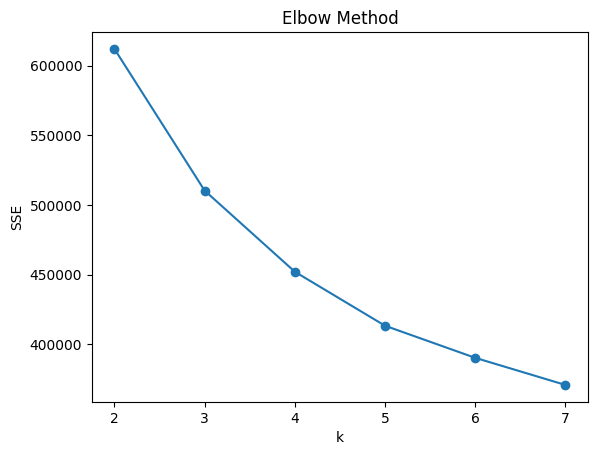

k=2, Silhouette Score=0.20854905806850998
k=3, Silhouette Score=0.24836029162851986
k=4, Silhouette Score=0.2391017858499692
k=5, Silhouette Score=0.19655208974787844
k=6, Silhouette Score=0.19606079324365813
k=7, Silhouette Score=0.1801987199143013


In [56]:
sse = []
silhouette_scores = []

K = range(2, 8)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_df)
    
    sse.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_df, labels))

# Plot Elbow
plt.plot(K, sse, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("SSE")
plt.show()

# Print silhouette
for k, score in zip(K, silhouette_scores):
    print(f"k={k}, Silhouette Score={score}")

In [57]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = kmeans.fit_predict(scaled_df)

data['cluster'] = clusters
data_clean['cluster'] = clusters

In [58]:
print(data['cluster'].value_counts())

cluster
1    46361
2    26585
0    12481
Name: count, dtype: int64


In [59]:
cluster_profile = data_clean.groupby('cluster').mean()
print(cluster_profile)

         danceability    energy   loudness  speechiness  acousticness  \
cluster                                                                 
0            0.662900  0.465172 -13.437934     0.830749      0.590230   
1            0.627197  0.693960  -7.623775     0.077264      0.259626   
2            0.484370  0.312803 -13.200348     0.056639      0.744498   

         instrumentalness  liveness   valence       tempo  
cluster                                                    
0                0.001360  0.441943  0.581196   99.983504  
1                0.051774  0.199510  0.668168  124.955038  
2                0.166518  0.177953  0.410923  111.948790  


In [61]:
print(data.groupby('cluster')['main_genre'].agg(lambda x: x.mode()[0]))

cluster
0             hoerspiel
1               unknown
2    vintage taiwan pop
Name: main_genre, dtype: str


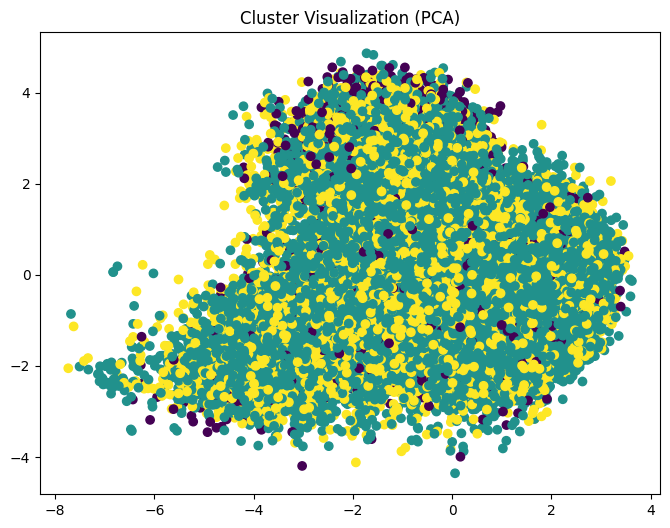

In [62]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = data['cluster']

plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['cluster'])
plt.title("Cluster Visualization (PCA)")
plt.show()

In [63]:
db_index = davies_bouldin_score(scaled_df, data['cluster'])
print("Davies-Bouldin Index:", db_index)

Davies-Bouldin Index: 1.524745821645564


In [66]:
data.to_csv("amazon_music_clustered_fixed.csv", index=False)